# Hands-on Week 4
---
## Introduction to Deep Learning and PyTorch

PyTorch is built around two core ideas:
1. **Tensors** — n-dimensional arrays with GPU support
2. **Autograd** — automatic differentiation: call `.backward()` and gradients flow

### The training loop (every DL model follows this)
```
for each batch:
    1. Forward pass:   output = model(input)
    2. Compute loss:   loss   = loss_fn(output, target)
    3. Zero gradients: optimiser.zero_grad()
    4. Backward pass:  loss.backward()          ← autograd!
    5. Update weights: optimiser.step()         ← gradient descent
```

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader


torch.manual_seed(42)
np.random.seed(42)

# Creating tensors
a = torch.tensor([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])

print(f"Tensor a:\n{a}")
print(f"Shape:  {a.shape}")
print(f"Dtype:  {a.dtype}")
print(f"Device: {a.device}")
print("-" * 40)

# Common operations (mirror NumPy)
print(f"\nSum:         {a.sum()}")
print(f"Mean:        {a.mean():.4f}")
print(f"Shape after T: {a.T.shape}")
print(f"Matrix mul:  \n{a @ a.T}")

Tensor a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape:  torch.Size([2, 3])
Dtype:  torch.float32
Device: cpu
----------------------------------------

Sum:         21.0
Mean:        3.5000
Shape after T: torch.Size([3, 2])
Matrix mul:  
tensor([[14., 32.],
        [32., 77.]])


## Training a Perceptron with Pytorch

In [3]:
# Generate synthetic data
X_line = torch.linspace(-3, 3, 60).unsqueeze(1)
y_line = 2 * X_line + 1 + 0.4 * torch.randn_like(X_line)

# Model: one linear layer (y = Wx + b)
model = nn.Linear(1, 1)
optimiser = optim.SGD(model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

losses = []
EPOCHS = 200

for epoch in range(EPOCHS):
    pred = model(X_line)                  # 1. Forward
    loss = loss_fn(pred, y_line)          # 2. Loss
    optimiser.zero_grad()                 # 3. Zero grads
    loss.backward()                       # 4. Backward
    optimiser.step()                      # 5. Update
    losses.append(loss.item())

W_learned = model.weight.item()
b_learned = model.bias.item()
print(f"True:    y = 2.0x + 1.0")
print(f"Learned: y = {W_learned:.3f}x + {b_learned:.3f}")

True:    y = 2.0x + 1.0
Learned: y = 1.954x + 1.010


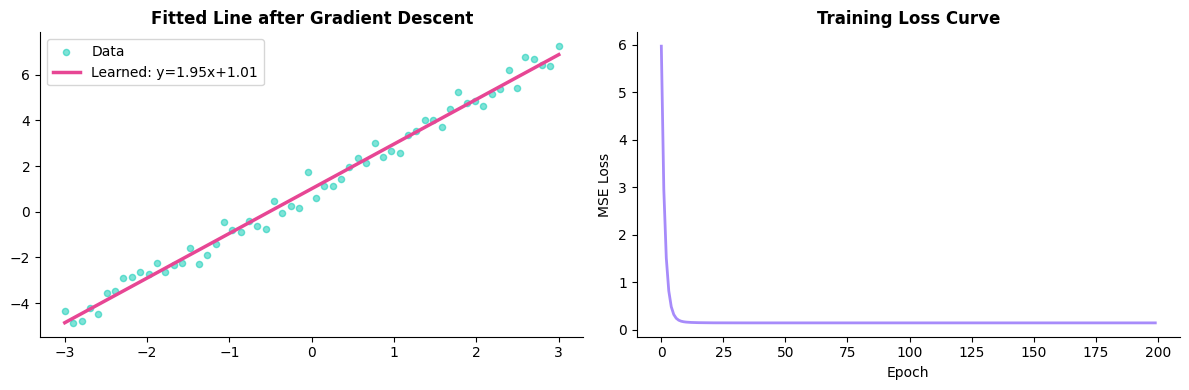

In [4]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X_line.numpy(), y_line.numpy(), alpha=0.5, s=20, color="#00C9B1", label="Data")
with torch.no_grad():
    y_fit = model(X_line)
ax1.plot(X_line.numpy(), y_fit.numpy(), color="#E74694", lw=2.5, label=f"Learned: y={W_learned:.2f}x+{b_learned:.2f}")
ax1.set_title("Fitted Line after Gradient Descent", fontweight="bold")
ax1.legend()
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.plot(losses, color="#A78BFA", lw=2)
ax2.set_title("Training Loss Curve", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE Loss")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Word Embeddings: the DL alternative to TF-IDF

Each word in our text corpus receives an ID and each ID corresponds to an ```embedding``` (a vector with a fixed dimension $d$). These embeddings are learned during training, such that similar or related words appear closer in the embedding space than unrelated words

In [5]:
# Load the data into Python
texts, labels = [], []
with open("../../data/lang_detection.txt", "r", encoding="utf-8") as f:
    for line in f:
        sentence, label = line.strip().split("\t")
        texts.append(sentence)
        labels.append(label)

y = np.array(labels)

word_corpus = []
for text in texts:
    word_corpus.extend([w.lower() for w in word_tokenize(text) if w.isalpha()])

In [6]:
word_to_id = {gram: i for i, gram in enumerate(word_corpus)}

In [7]:
def encode(text, max_seq_len=15):
    id_seq = [0] * max_seq_len
    for i, word in enumerate(word_tokenize(text)):
        if i >= max_seq_len:
            break
        if word.isalpha(): 
            id_seq[i] = word_to_id[word.lower()]
    return id_seq

In [8]:
# nn.Embedding is a trainable lookup table:
# vocab_size rows, each row = dense vector for one token
VOCAB_SIZE  = len(word_corpus) + 1
EMBED_DIM   = 32
MAX_SEQ_LEN = 5

token_ids = np.array([encode(text) for text in texts])
token_ids

array([[  0,   1,   0, ...,   0,   0,   0],
       [  2, 185, 152, ...,   0,   0,   0],
       [154, 171,   7, ...,   0,   0,   0],
       ...,
       [551, 552, 553, ...,   0,   0,   0],
       [555, 556, 557, ...,   0,   0,   0],
       [559, 560, 561, ...,   0,   0,   0]], shape=(150, 15))

In [9]:
class SentenceDataset(Dataset):
    def __init__(self, texts, labels, max_seq_len=MAX_SEQ_LEN):
        self.texts = texts
        self.labels = labels
        self.max_seq_len = max_seq_len
        unique_labels = sorted(set(labels))
        self.label_to_idx = {label: i for i, label in enumerate(unique_labels)}
        self.num_classes = len(unique_labels)
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        label_id = self.label_to_idx[label]
        token_ids = torch.tensor(encode(text, self.max_seq_len)).long()
        return (
            text,
            token_ids,
            label_id,
        )

texts_train, texts_test, labels_train, labels_test = train_test_split(texts, labels, test_size=0.1)

train_dataset = SentenceDataset(texts_train, labels_train)
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)


### Recurrent Neural Networks: the DL alternative to "pooling"

Recurrent neural networks (RNNs) extend feedforward architectures to handle sequential data by maintaining an internal state that persists across input elements. For each element $i=1,\ldots,n$ in a sequence, an RNN receives an input $x_t$ and updates its hidden state $h_t$ based on both the input and the previous hidden state $h_{t-1}$. This recurrent connection enables the network to maintain information about past inputs, making RNNs suitable for processing sequences of arbitrary length.
In its most fundamental form, the transition is defined as $h_t = \tanh(W_{h} h_{t-1} + W_{x} x_t + b)$, where $W_{h}$ and $W_{x}$ are learnable weight matrices

In [10]:
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.1):
        super(RNNEncoder, self).__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Disable bias on h2h to avoid doubling the bias term
        self.i2h = nn.Linear(embed_dim, hidden_dim, bias=True)
        self.h2h = nn.Linear(hidden_dim, hidden_dim, bias=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size, seq_len = x.shape

        embedded = self.dropout(self.embedding(x))  # regularize embeddings

        # Cleaner device handling — no intermediate .to() copy
        h_t = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        for t in range(seq_len):
            x_t = embedded[:, t, :]
            h_t = torch.tanh(self.i2h(x_t) + self.h2h(h_t))

        return h_t

class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(TextClassifier, self).__init__()
        self.rnn = RNNEncoder(vocab_size, embed_dim, hidden_dim)
        self.lin = nn.Linear(embed_dim, num_classes)

    def forward(self, token_ids):
        text_emb = self.rnn(token_ids)
        return self.lin(text_emb)

In [11]:
model = TextClassifier(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=EMBED_DIM, num_classes=3)
optimiser = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

DEVICE = "cpu"
EPOCHS = 500
train_losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for text, token_ids, label in train_dataloader:
        token_ids = token_ids.to(DEVICE)
        label = label.to(DEVICE)
        logits = model(token_ids)                        # (B, num_classes)

        # CrossEntropyLoss expects logits of shape (B, num_classes) and label ids of shape (num_classes,)
        loss = loss_fn(
            logits.view(-1, 3),
            label.view(-1)
        )
        optimiser.zero_grad()
        loss.backward()
        # Gradient clipping prevents exploding gradients in RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  |  Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Epoch  50/500  |  Loss: 0.6502
Epoch 100/500  |  Loss: 0.2060
Epoch 150/500  |  Loss: 0.0608
Epoch 200/500  |  Loss: 0.0138
Epoch 250/500  |  Loss: 0.0068
Epoch 300/500  |  Loss: 0.0022
Epoch 350/500  |  Loss: 0.0011
Epoch 400/500  |  Loss: 0.0013
Epoch 450/500  |  Loss: 0.0009
Epoch 500/500  |  Loss: 0.0001

Training complete!


In [12]:
test_dataset = SentenceDataset(texts_test, labels_test)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=True)

In [13]:
correct = 0
incorrect = 0
model.train(False)
for text, token, label in test_dataloader:
    token = token.to(DEVICE)
    label = label.to(DEVICE)
    logits = model(token) 
    pred = torch.argmax(logits, dim=-1)
    correct += int((label == pred).sum())
    incorrect += int((label != pred).sum())

In [14]:
correct / (correct + incorrect) * 100

73.33333333333333